In [3]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("TensorFlow path:", tf.__file__)


TensorFlow version: 2.16.1
TensorFlow path: C:\Users\manes\anaconda3\envs\tf\lib\site-packages\tensorflow\__init__.py


In [4]:
# Safe TensorFlow import & diagnostics cell
import os, sys
print("Python:", sys.version)
print("Working dir:", os.getcwd())

# Prevent TF trying to use GPU/CUDA (avoid DLL errors)
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

errors = []

try:
    import tensorflow as tf
    # If tf appears but lacks version attribute, it's a sign of a corrupted module
    try:
        print("TensorFlow version:", tf.__version__)
        print("TensorFlow import OK. Path:", tf.__file__)
    except Exception as e:
        errors.append("TensorFlow imported but tf.__version__ failed: " + repr(e))
except Exception as e:
    errors.append("TensorFlow import failed: " + repr(e))

if errors:
    print("\\n--- DIAGNOSTICS ---")
    for e in errors:
        print(e)
    print("\\nIf you see errors, do these:")
    print("1) Ensure you installed 'tensorflow-cpu' (pip install tensorflow-cpu==2.16.1).")
    print("2) Make sure there's no local file/folder named 'tensorflow' in the notebook directory.")
    print("3) Reinstall VC++ Redistributable and restart Windows.")
    # Stop further cells from running automatically
    raise SystemExit("TensorFlow not available — follow the diagnostics above.")
else:
    # Set TF to use CPU only (explicit)
    tf.config.set_visible_devices([], 'GPU')


Python: 3.10.18 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:08:55) [MSC v.1929 64 bit (AMD64)]
Working dir: C:\Users\manes
TensorFlow version: 2.16.1
TensorFlow import OK. Path: C:\Users\manes\anaconda3\envs\tf\lib\site-packages\tensorflow\__init__.py


In [5]:
import os
BASE_PATH = r"C:\Users\manes\Downloads\archive (9)"
PART1 = os.path.join(BASE_PATH, "HAM10000_images_part_1")
PART2 = os.path.join(BASE_PATH, "HAM10000_images_part_2")
META = os.path.join(BASE_PATH, "HAM10000_metadata.csv")

print("PART1 exists?", os.path.exists(PART1))
print("PART2 exists?", os.path.exists(PART2))
print("META exists? ", os.path.exists(META))

# quick list few files
if os.path.exists(PART1):
    print("Example file in PART1:", os.listdir(PART1)[:5])


PART1 exists? True
PART2 exists? True
META exists?  True
Example file in PART1: ['ISIC_0024306.jpg', 'ISIC_0024307.jpg', 'ISIC_0024308.jpg', 'ISIC_0024309.jpg', 'ISIC_0024310.jpg']


In [8]:
# Core imports
import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import to_categorical

# small helper: find images across both folders
def find_image(image_id):
    name = image_id + ".jpg"
    p1 = os.path.join(PART1, name)
    p2 = os.path.join(PART2, name)
    if os.path.exists(p1): return p1
    if os.path.exists(p2): return p2
    return None


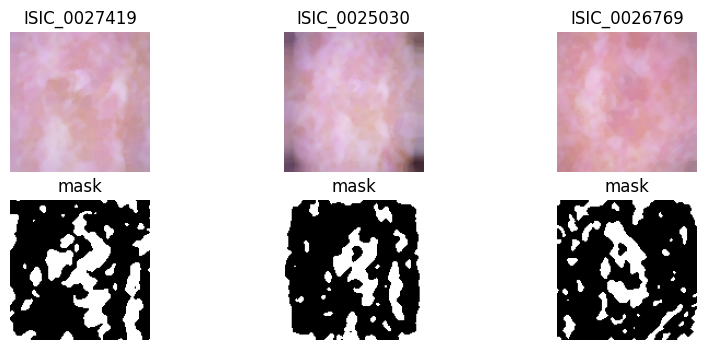

In [9]:
def preprocess_image_cv(path, size=(128,128)):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    # quick denoise
    img = cv2.medianBlur(img, 5)
    # hair removal via blackhat + inpaint
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17,17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    # small blur of mask
    mask = cv2.medianBlur(mask, 3)
    inpainted = cv2.inpaint(img, mask, 1, cv2.INPAINT_TELEA)
    return inpainted, mask

# quick display of 3 examples (adjust n)
meta = pd.read_csv(META)
sample_ids = meta['image_id'].dropna().unique()[:3]
plt.figure(figsize=(10,4))
for i, imgid in enumerate(sample_ids):
    p = find_image(imgid)
    img, mask = preprocess_image_cv(p)
    plt.subplot(2,3,i+1); plt.imshow(img); plt.title(imgid); plt.axis('off')
    plt.subplot(2,3,i+4); plt.imshow(mask, cmap='gray'); plt.title('mask'); plt.axis('off')
plt.show()


In [10]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model

def simple_unet_tf(input_size=(128,128,3), n_filters=32):
    inputs = Input(shape=input_size)
    # encoder
    c1 = Conv2D(n_filters, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(n_filters, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(n_filters*2, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(n_filters*2, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2,2))(c2)

    b = Conv2D(n_filters*4, 3, activation='relu', padding='same')(p2)
    b = Conv2D(n_filters*4, 3, activation='relu', padding='same')(b)

    u1 = UpSampling2D((2,2))(b)
    m1 = concatenate([u1, c2], axis=-1)
    c3 = Conv2D(n_filters*2, 3, activation='relu', padding='same')(m1)
    c3 = Conv2D(n_filters*2, 3, activation='relu', padding='same')(c3)

    u2 = UpSampling2D((2,2))(c3)
    m2 = concatenate([u2, c1], axis=-1)
    c4 = Conv2D(n_filters, 3, activation='relu', padding='same')(m2)
    c4 = Conv2D(n_filters, 3, activation='relu', padding='same')(c4)

    outputs = Conv2D(1, 1, activation='sigmoid')(c4)
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

unet = simple_unet_tf()
# print summary safely
from io import StringIO
stream = StringIO()
unet.summary(print_fn=lambda line: stream.write(line+"\n"))
print(stream.getvalue())


Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 128, 128, 32)      │             896 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 128, 128, 32)      │           9,248 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤

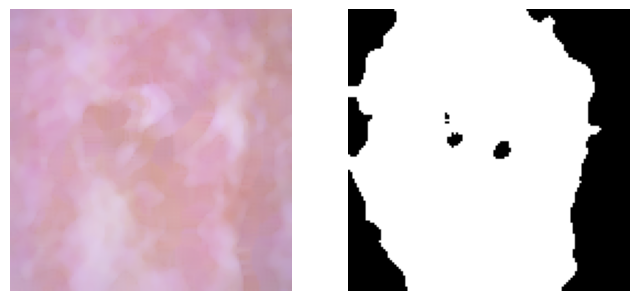

In [11]:
def quick_segment_demo(img_rgb):
    # img_rgb = (H,W,3) uint8
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    v = hsv[:,:,2]
    _, m = cv2.threshold(v, 0, 255, cv2.THRESH_OTSU)
    m = cv2.medianBlur(m, 5)
    # normalize to 0-1
    return (m/255).astype('float32')

# demo using the preprocessed image
p = find_image(sample_ids[0])
img, mask = preprocess_image_cv(p)
seg = quick_segment_demo(img)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(seg, cmap='gray'); plt.axis('off')
plt.show()


In [12]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# build classifier
base = ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))
base.trainable = False
x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
preds = Dense(2, activation='softmax')(x)
clf = Model(inputs=base.input, outputs=preds)
clf.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Prepare a tiny demo dataset (nv vs mel), small subset for fast run
meta = pd.read_csv(META)
label_map = {'nv':0, 'mel':1}
demo_meta = meta[meta['dx'].isin(label_map)].sample(n=min(40,len(meta[meta['dx'].isin(label_map)])), random_state=42)
X=[]
Y=[]
for _, r in demo_meta.iterrows():
    p = find_image(r['image_id'])
    if p is None: continue
    img, _ = preprocess_image_cv(p, size=(128,128))
    arr = preprocess_input(img.astype('float32'))
    X.append(arr)
    Y.append(label_map[r['dx']])
X = np.stack(X,0)
Y = to_categorical(Y, num_classes=2)
print("Demo X shape:", X.shape, "Y shape:", Y.shape)

# tiny train (1-3 epochs) 
if X.shape[0] >= 8:
    clf.fit(X, Y, epochs=2, batch_size=8, validation_split=0.2)
else:
    print("Not enough demo samples to train the classifier.")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Demo X shape: (40, 128, 128, 3) Y shape: (40, 2)
Epoch 1/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7500 - loss: 2.6741 - val_accuracy: 1.0000 - val_loss: 3.0551e-04
Epoch 2/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - accuracy: 0.8438 - loss: 1.1703 - val_accuracy: 1.0000 - val_loss: 0.0503


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


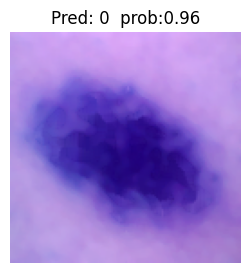

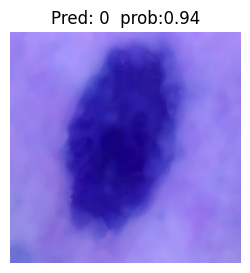

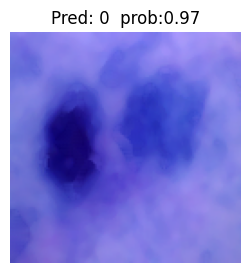

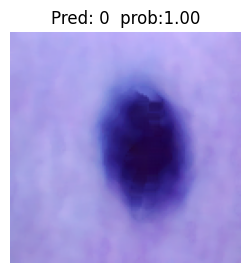

In [13]:
# Take first 4 samples for predictions
if X.shape[0] > 0:
    preds = clf.predict(X[:4])
    for i in range(min(4, X.shape[0])):
        plt.figure(figsize=(3,3))
        img_show = ((X[i] - X[i].min())/(X[i].ptp())*255).astype('uint8')
        plt.imshow(img_show)
        plt.title(f"Pred: {np.argmax(preds[i])}  prob:{preds[i].max():.2f}")
        plt.axis('off')
        plt.show()
